In [1]:
import pandas as pd
import numpy as np

# Cargar el dataset
airbnb = pd.read_csv('/content/Listings.csv', encoding="ISO-8859-1", low_memory=False)

Encoding "ISO-8859-1": usa esto porque el archivo original probablemente contiene caracteres especiales (como acentos en nombres de barrios franceses) que el formato UTF-8 estándar no puede procesar, evitando errores de lectura.

Low_memory=False: Se usa para que Pandas procese el archivo de forma más exhaustiva y no cometa errores al adivinar los tipos de datos en columnas grandes.

Inspección Inicial (Exploración de Metadatos)

In [2]:
airbnb.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2.0,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2.0,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2.0,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2.0,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2.0,1125.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [3]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24695 entries, 0 to 24694
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   listing_id                   24695 non-null  int64  
 1   name                         24631 non-null  object 
 2   host_id                      24695 non-null  int64  
 3   host_since                   24694 non-null  object 
 4   host_location                24604 non-null  object 
 5   host_response_time           0 non-null      float64
 6   host_response_rate           0 non-null      float64
 7   host_acceptance_rate         4733 non-null   float64
 8   host_is_superhost            24694 non-null  object 
 9   host_total_listings_count    24694 non-null  float64
 10  host_has_profile_pic         24694 non-null  object 
 11  host_identity_verified       24694 non-null  object 
 12  neighbourhood                24694 non-null  object 
 13  district        

El dataset contiene 24,695 registros y 33 columnas.

Preprocesamiento: Conversión de Tipos

Por defecto, las fechas se cargan como "objetos" (texto). Convertirlas a formato datetime permite realizar análisis temporales, como calcular la antigüedad de un anfitrión o ver cómo han crecido los listados a lo largo de los años.

Convertir cualquier columna de fecha en formato de fecha y hora

In [4]:
airbnb["host_since"] = pd.to_datetime(airbnb["host_since"])

Filtrado y Selección (Enfoque en París)
El análisis se reduce específicamente a la ciudad de París.

En ciencia de datos, "menos es más". Al reducir el ruido y centrarnos en una sola ciudad y en las variables que realmente afectan el negocio (ubicación, capacidad y precio), el análisis se vuelve mucho más profundo y relevante para la toma de decisiones.

In [5]:
paris_listados = (airbnb
.query("city == 'Paris'")
.loc[:, ["host_since", "neighbourhood", "city", "accommodates", "price"]]
)

paris_listados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14881 entries, 0 to 24631
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     14881 non-null  datetime64[ns]
 1   neighbourhood  14881 non-null  object        
 2   city           14881 non-null  object        
 3   accommodates   14881 non-null  float64       
 4   price          14881 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 697.5+ KB


In [6]:
paris_listados.isna().sum()

,0
host_since,0
neighbourhood,0
city,0
accommodates,0
price,0


Análisis Estadístico Descriptivo

In [7]:
paris_listados.describe()

,host_since,accommodates,price
count,14881,14881.000000,14881.000000
mean,2015-08-02 19:15:41.791546368,2.975539,93.640414
min,2009-10-28 00:00:00,1.000000,8.000000
25%,2014-04-14 00:00:00,2.000000,60.000000
50%,2015-05-22 00:00:00,2.000000,79.000000
75%,2016-06-29 00:00:00,4.000000,100.000000
max,2020-12-16 00:00:00,14.000000,6742.000000
std,NaN,1.273729,96.450945


Precio Medio: El precio promedio de una estancia en París es de 93.64 €.

Capacidad (Accommodates): El promedio es de 2.97 personas, lo que sugiere que la mayoría de los alojamientos son para parejas o grupos pequeños.

Detección de Outliers (Valores Atípicos): El precio máximo es de 6,742 €. Comparado con la media de 93 €, esto indica la presencia de alojamientos de ultra-lujo o posibles errores de entrada de datos. Como científico de datos, esto me advierte que si planeo hacer un modelo de regresión, estos valores extremos podrían sesgar los resultados.

In [8]:
paris_listados.query("accommodates == 0")#.count

,host_since,neighbourhood,city,accommodates,price


Preparar los datos para la visualización

Su segundo objetivo es producir DataFrames que se utilizarán en visualizaciones agregando y manipulando los datos de listados de varias maneras.

tabla que agrupa los listados de París por "barrio" y calcule el precio medio (ordenado de menor a mayor).

In [9]:
paris_listados_neighbourhood = (
    paris_listados
    .groupby("neighbourhood")
    .agg({"price": "mean"})
    .sort_values("price")
)

paris_listados_neighbourhood.head()

,price
neighbourhood,
Buttes-Chaumont,72.224781
Menilmontant,73.804124
Reuilly,80.680180
Popincourt,81.006862
Gobelins,83.964684


tabla que filtra hasta el vecindario más caro, agrupe por la columna 'alojamiento' y agregue el precio promedio para cada valor de 'alojamiento' (ordenado de menor a mayor).

In [10]:
paris_listados_accommodates = (
    paris_listados
    .query("neighbourhood == 'Elysee'")
    .groupby("accommodates")
    .agg({"price": "mean", "neighbourhood": "count"})
    .sort_values("price")
)

paris_listados_accommodates.head()

,price,neighbourhood
accommodates,,
1.0,56.750000,4
2.0,95.330275,109
3.0,107.250000,24
4.0,155.722222,72
5.0,241.800000,10


tabla agrupada por el año 'host_since' y calcule el precio promedio y el recuento de filas que representan la cantidad de nuevos hosts.

In [11]:
paris_listados_over_time = (
    paris_listados
    .set_index("host_since")
    .resample("YE")
    .agg({
        "neighbourhood": "count",
        "price": "mean"})
)

paris_listados_over_time.head()

,neighbourhood,price
host_since,,
2009-12-31,2,93.000000
2010-12-31,39,101.641026
2011-12-31,232,96.689655
2012-12-31,803,90.089664
2013-12-31,1925,91.671688


Visualizar los datos y resumir los hallazgo

Su objetivo final es crear elementos visuales que muestren la cantidad de nuevos anfitriones por año, el precio promedio general por año y vecindario, y el precio promedio de varios tipos de anuncios en el vecindario más caro de París.

gráfico de barras horizontales del precio promedio por barrio en París y asegúrese de agregar un título y cambiar las etiquetas de los ejes según sea necesario.

In [12]:
import seaborn as sns

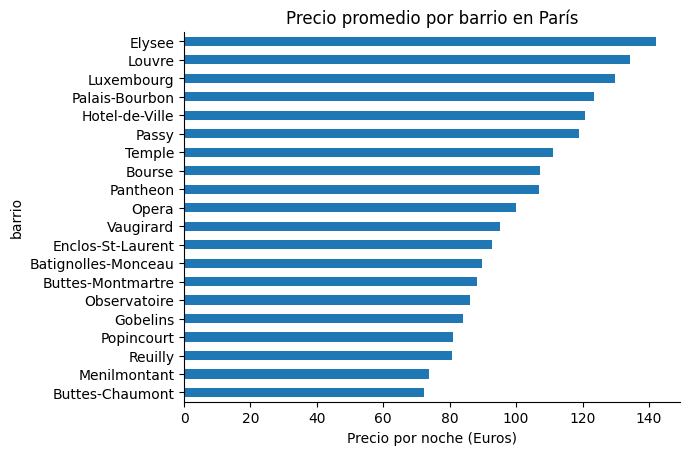

In [13]:
(paris_listados_neighbourhood
 .plot
 .barh(
     title = "Precio promedio por barrio en París",
     xlabel = "Precio por noche (Euros)",
     ylabel = "barrio",
     legend = None
 )
)

sns.despine()

gráfico de barras horizontales del precio promedio por alojamiento en el barrio más caro de París

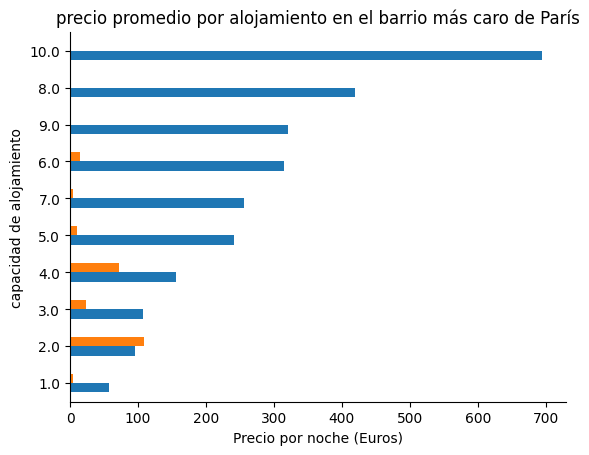

In [14]:
(paris_listados_accommodates
 .plot
 .barh(
     title = "precio promedio por alojamiento en el barrio más caro de París",
     xlabel = "Precio por noche (Euros)",
     ylabel = "capacidad de alojamiento",
     legend = None
 )
)

sns.despine()

dos gráficos de líneas: uno que muestre el número de nuevos hosts a lo largo del tiempo y otro que muestre el precio promedio. Establezca el límite del eje Y en 0, añada un título y modifique las etiquetas de los ejes según sea necesario.

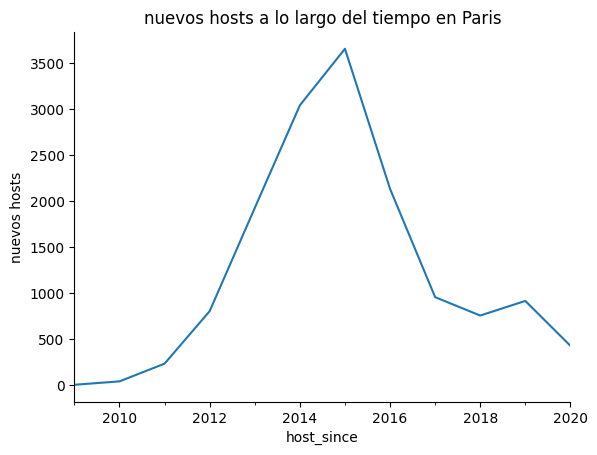

In [15]:
paris_listados_over_time["neighbourhood"].plot(
    ylabel="nuevos hosts",
    title="nuevos hosts a lo largo del tiempo en Paris"
)

sns.despine()

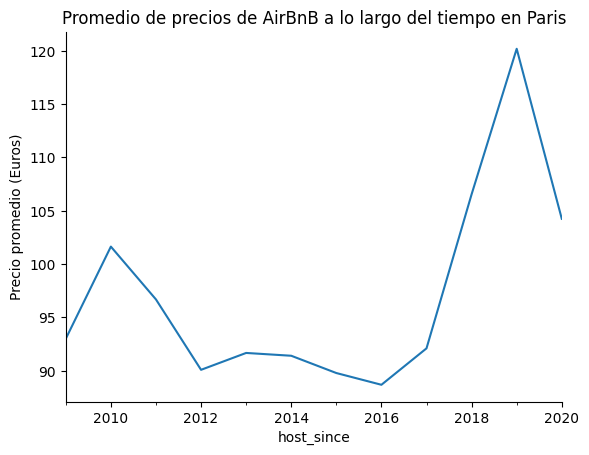

In [16]:
paris_listados_over_time["price"].plot(
    ylabel="Precio promedio (Euros)",
    title="Promedio de precios de AirBnB a lo largo del tiempo en Paris"
)

sns.despine()

Text(0.5, 1.0, 'Las regulaciones de 2015 dan lugar a menos anfitriones nuevos y precios más altos')

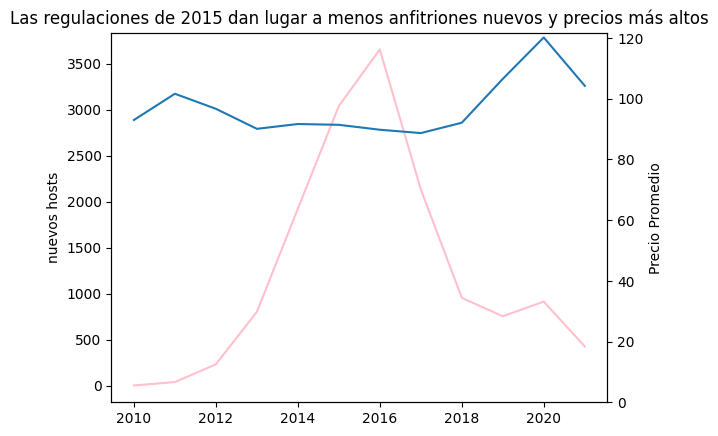

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(
    paris_listados_over_time.index,
    paris_listados_over_time["neighbourhood"],
    label="New Hosts",
    c="pink"
)
ax.set_ylabel("nuevos hosts")

ax2 = ax.twinx()
ax2.plot(
    paris_listados_over_time.index,
    paris_listados_over_time["price"],
    label="Average Price",
)
ax2.set_ylim(0)

ax2.set_ylabel("Precio Promedio")
ax.set_title("Las regulaciones de 2015 dan lugar a menos anfitriones nuevos y precios más altos")